# Full Kalman/Transformer State-Estimation Walk-Through

This notebook produces a somewhat more extended set of results than in `demo.ipynb`. The defaults here are chosen such that the notebook can still be run in ~10 minutes on a modern laptop, while retaining the flavor of the full results.

We will train Transformers from scratch and compare them to:

1. A Kalman filter under Gaussian noise, where the Kalman filter is Bayes optimal
2. An unrolled Kalman coefficient matrix, compared to an unrolled Transformer coefficient matrix, showing that they implement the same "linear regression algorithm"
3. A Kalman filter under half-Gaussian transition noise, where the Gaussian assumptions are violated.

## 0. Environment setup

This repository uses `uv` for environment management. Run the next cell once from the repository root to create `./.venv`, install dependencies, and register a Jupyter kernel. After it finishes, select the `Python (demo)` kernel.

The default install uses the CPU-compatible JAX package from `requirements.txt`. If your machine has an NVIDIA GPU, uncomment the GPU-enabled JAX install lines after checking the current JAX installation guide: https://docs.jax.dev/en/latest/installation.html

In [ ]:
# Install dependencies. Run once from the repository root.
!uv venv
!uv pip install -r requirements.txt

# Optional NVIDIA GPU-enabled JAX installs.
# !uv pip install -U "jax[cuda13]"

!uv run python -m ipykernel install --user --name filter-demo --display-name "Python (demo)"

## 1. Imports and runtime check

The notebook draws directly on the repository implementation:

- `task/filter.py`: synthetic state-estimation task and Kalman baseline,
- `model/transformer.py`: Transformer architecture,
- `train.py`: training loop and evaluation utilities,
- `common.py`: plotting style and small utilities.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import time

import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from common import set_theme
from model.transformer import TransformerConfig
from task.filter import KalmanFilterTask, pred_kalman
from train import train

set_theme()
pd.set_option("display.max_columns", 80)

print(f"JAX version: {jax.__version__}")
print(f"JAX devices: {jax.devices()}")

JAX version: 0.10.0
JAX devices: [CudaDevice(id=0)]


## 2. Settings

The values below are the main knobs for the live run. Increasing `*_ITERS`, dimensions, widths, and batch sizes moves the notebook closer to full-scale experiments; decreasing them makes the notebook faster but noisier.

The train/test boundary in the plots is set by the training sequence length. Evaluation uses a longer sequence to show extrapolation beyond the length seen during training.

In [2]:
@dataclass
class NotebookConfig:
    # Gaussian varying-AC experiment, matching the demo task except for the longer sweep.
    gaussian_n_dims: int = 4
    gaussian_train_length: int = 16
    gaussian_eval_length: int = 32
    gaussian_t_noise: float = 1.0
    gaussian_o_noise: float = 0.01
    gaussian_batch_size: int = 128
    gaussian_eval_batch_size: int = 512
    gaussian_iters: int = 5000
    gaussian_lr: float = 1e-4

    # Interpretable coefficient-regression model.
    coeff_n_dims: int = 32
    coeff_train_length: int = 16
    coeff_eval_length: int = 16
    coeff_noise: float = 0.1
    coeff_batch_size: int = 128
    coeff_eval_batch_size: int = 512
    coeff_iters: int = 5000
    coeff_lr: float = 1e-4

    # Half-Gaussian model-mismatch experiment, using the same task scale as the demo.
    half_n_dims: int = 4
    half_train_length: int = 16
    half_eval_length: int = 32
    half_t_noise: float = 1.0
    half_o_noise: float = 0.01
    half_batch_size: int = 128
    half_eval_batch_size: int = 512
    half_iters: int = 5000
    half_lr: float = 1e-4

    seed: int = 7

CFG = NotebookConfig()
CFG

NotebookConfig(gaussian_n_dims=4, gaussian_train_length=16, gaussian_eval_length=32, gaussian_t_noise=1.0, gaussian_o_noise=0.01, gaussian_batch_size=128, gaussian_eval_batch_size=512, gaussian_iters=5000, gaussian_lr=0.0001, coeff_n_dims=32, coeff_train_length=16, coeff_eval_length=16, coeff_noise=0.1, coeff_batch_size=128, coeff_eval_batch_size=512, coeff_iters=5000, coeff_lr=0.0001, half_n_dims=4, half_train_length=16, half_eval_length=32, half_t_noise=1.0, half_o_noise=0.01, half_batch_size=128, half_eval_batch_size=512, half_iters=5000, half_lr=0.0001, seed=7)

## 3. Helpers

In [3]:
def timed_train(label, config, task, train_iters, lr, test_every=None):
    """Train one Transformer and print wall-clock time."""
    if test_every is None:
        test_every = 1000

    start = time.time()
    state, hist = train(
        config,
        data_iter=iter(task),
        test_iter=iter(task),
        train_iters=train_iters,
        test_iters=1,
        test_every=test_every,
        seed=CFG.seed,
        lr=lr,
    )
    elapsed = time.time() - start
    print(f"{label}: {elapsed:.1f} seconds")
    return state, hist


def gaussian_sweep_config(pos_emb):
    return TransformerConfig(
        n_layers=2,
        n_hidden=256,
        n_heads=2,
        n_mlp_layers=2,
        pos_emb=pos_emb,
        layer_norm=True,
        residual_connections=True,
        return_final_logits_only=False,
        n_out=CFG.gaussian_n_dims,
    )


def coeff_config():
    # This deliberately simple architecture makes the learned linear map easy to unroll.
    return TransformerConfig(
        n_layers=1,
        n_hidden=256,
        n_heads=1,
        n_mlp_layers=0,
        pos_emb=False,
        layer_norm=False,
        residual_connections=False,
        return_final_logits_only=False,
        n_out=CFG.coeff_n_dims,
    )


def half_sweep_config(pos_emb):
    return TransformerConfig(
        n_layers=2,
        n_hidden=256,
        n_heads=2,
        n_mlp_layers=2,
        pos_emb=pos_emb,
        layer_norm=True,
        residual_connections=True,
        return_final_logits_only=False,
        n_out=CFG.half_n_dims,
    )


def set_task_shape(task, length, batch_size):
    task.length = length
    task.batch_size = batch_size
    return task


def split_ac_batch(xs, task):
    """Split a mode='ac' batch into transition matrices, observation matrices, and observations."""
    n_dims = task.n_dims
    n_obs_dims = task.n_obs_dims
    A = xs[:, :n_dims, n_obs_dims:]
    C = xs[:, n_dims:n_dims + n_obs_dims, n_obs_dims:]
    observations = xs[:, n_dims + n_obs_dims:, :n_obs_dims]
    return A, C, observations


def plot_mse_sweep(df, title, train_length, yscale="log", ylim=None):
    fig, ax = plt.subplots(figsize=(7.5, 3.0))
    hue_order = [
        "Transformer (NoPE)",
        "Transformer (absolute PE)",
        "Kalman filter",
        "Bayes/Kalman theory",
        "Zero predictor",
    ]
    palette = {
        "Transformer (NoPE)": "C9",
        "Transformer (absolute PE)": "C0",
        "Kalman filter": "C1",
        "Bayes/Kalman theory": "red",
        "Zero predictor": "C8",
    }
    marker_df = df[df["method"] != "Bayes/Kalman theory"]
    marker_order = [label for label in hue_order if label in set(marker_df["method"])]
    if not marker_df.empty:
        sns.lineplot(
            data=marker_df,
            x="time",
            y="mse",
            hue="method",
            hue_order=marker_order,
            palette=palette,
            marker="o",
            linewidth=1.5,
            alpha=0.85,
            ax=ax,
        )

    theory_df = df[df["method"] == "Bayes/Kalman theory"]
    if not theory_df.empty:
        sns.lineplot(
            data=theory_df,
            x="time",
            y="mse",
            color=palette["Bayes/Kalman theory"],
            alpha=0.8,
            linewidth=1.8,
            marker=None,
            errorbar=None,
            label="Bayes/Kalman theory",
            ax=ax,
        )

    boundary = train_length - 2
    ax.axvline(boundary, linestyle="--", color="0.45", linewidth=1)
    ax.text(boundary + 0.5, ax.get_ylim()[1] * 0.85, "train/test", color="0.35", fontsize=9)
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel("MSE")
    if yscale is not None:
        ax.set_yscale(yscale)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend(title=None, frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))
    fig.tight_layout()
    return fig, ax

## 4. Gaussian noise: Transformer versus the Bayes-optimal Kalman filter

In the classical linear-Gaussian state-space model, the Kalman filter is the Bayes-optimal estimator. This first experiment trains two Transformers on a fixed system: one with no positional encoding (NoPE) and one with absolute positional encodings. We demonstrate that Transormers approach Bayes-optimal on this task, and can generalize well in the absence of positional encodings.

The important workflow details are:

- The task object defines the latent transition matrix, observation matrix, noise model, and sequence length
- The Transformer is trained by next-observation prediction
- Evaluation compares the Transformer to both empirical Kalman MSE and the theoretical Kalman prediction variance.

In [4]:
gaussian_task = KalmanFilterTask(
    length=CFG.gaussian_train_length,
    n_dims=CFG.gaussian_n_dims,
    n_obs_dims=CFG.gaussian_n_dims,
    mode="ac",
    n_tasks=None,
    n_snaps=None,
    t_noise=CFG.gaussian_t_noise,
    o_noise=CFG.gaussian_o_noise,
    noise_dist="gauss",
    batch_size=CFG.gaussian_batch_size,
    seed=CFG.seed,
)

gaussian_states = {}
gaussian_histories = {}

for label, pos_emb in [("Transformer (NoPE)", False), ("Transformer (absolute PE)", True)]:
    set_task_shape(gaussian_task, CFG.gaussian_train_length, CFG.gaussian_batch_size)
    state, hist = timed_train(
        label,
        gaussian_sweep_config(pos_emb),
        gaussian_task,
        train_iters=CFG.gaussian_iters,
        lr=CFG.gaussian_lr,
    )
    gaussian_states[label] = state
    gaussian_histories[label] = hist

ITER 1000:  train_loss=0.4955   test_loss=0.4611
ITER 2000:  train_loss=0.4483   test_loss=0.4458
ITER 3000:  train_loss=0.4406   test_loss=0.4393
ITER 4000:  train_loss=0.4347   test_loss=0.4236
ITER 5000:  train_loss=0.4321   test_loss=0.4389
Transformer (NoPE): 63.2 seconds
ITER 1000:  train_loss=0.4380   test_loss=0.3772
ITER 2000:  train_loss=0.3723   test_loss=0.3634
ITER 3000:  train_loss=0.3696   test_loss=0.3772
ITER 4000:  train_loss=0.3689   test_loss=0.3561
ITER 5000:  train_loss=0.3686   test_loss=0.3469
Transformer (absolute PE): 52.2 seconds


(<Figure size 750x300 with 1 Axes>,
 <Axes: title={'center': 'Gaussian varying-AC noise: Transformer, Kalman filter, and zero predictor'}, xlabel='Time', ylabel='MSE'>)

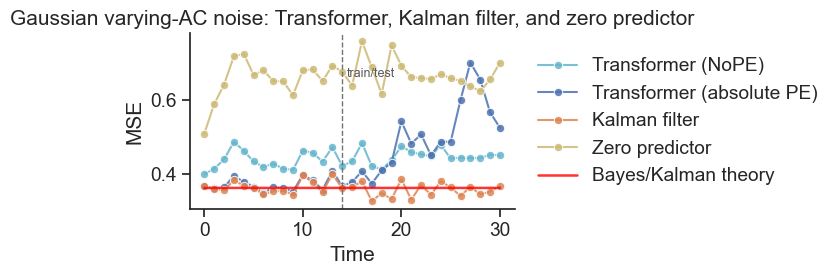

In [5]:
def evaluate_gaussian_models(states, task):
    set_task_shape(task, CFG.gaussian_eval_length, CFG.gaussian_eval_batch_size)
    xs_full = next(task)
    A, C, observations = split_ac_batch(xs_full, task)
    time_index = np.arange(observations.shape[1] - 1)

    rows = []
    obs_start = task.n_dims + task.n_obs_dims
    for label, state in states.items():
        pred_full = np.asarray(state.apply_fn({"params": state.params}, xs_full))
        pred_obs = pred_full[:, obs_start:-1, :task.n_obs_dims]
        mse = ((observations[:, 1:] - pred_obs) ** 2).mean(axis=(0, -1))
        rows.append(pd.DataFrame({"time": time_index, "mse": mse, "method": label}))

    kalman_pred, kalman_theory = pred_kalman(
        observations,
        task,
        A=A,
        C=C,
        t_noise=task.t_noise,
        o_noise=task.o_noise,
    )
    kalman_empirical = ((observations[:, 1:] - kalman_pred[:, :-1]) ** 2).mean(axis=(0, -1))
    zero_mse = (observations[:, 1:] ** 2).mean(axis=(0, -1))

    rows.extend([
        pd.DataFrame({"time": time_index, "mse": kalman_empirical, "method": "Kalman filter"}),
        pd.DataFrame({"time": time_index, "mse": np.asarray(kalman_theory[:-1]), "method": "Bayes/Kalman theory"}),
        pd.DataFrame({"time": time_index, "mse": zero_mse, "method": "Zero predictor"}),
    ])
    return pd.concat(rows, ignore_index=True)


gaussian_df = evaluate_gaussian_models(gaussian_states, gaussian_task)
plot_mse_sweep(
    gaussian_df,
    title="Gaussian varying-AC noise: Transformer, Kalman filter, and zero predictor",
    train_length=CFG.gaussian_train_length,
    yscale="linear",
)

The red curve is the theoretical Bayes-optimal MSE computed by the Kalman recursion. The empirical Kalman curve should track it closely. The Transformer curves are learned from next-step prediction only; when training succeeds, they approach the same performance without being given the Kalman recursion explicitly.

## 5. Unrolling the Kalman filter and the learned Transformer

For a fixed linear system, the Kalman filter can be "unrolled" as large linear map from previous observations to future predictions. This map can be written as a block lower-triangular coefficient matrix whose blocks tell us how each earlier observation contributes to each later prediction.

A one-layer, one-head, NoPE Transformer without MLPs, layer normalization, or residual connections can also be unrolled into a block coefficient matrix. Its coefficients come from the attention weights multiplied by a shared learned input/value/output map. The scatter plot below compares these two matrices entry by entry, showing that they are highly correlated. This suggests that, not only does the Transformer match Kalman performance, it appears to implement the same or a very similar algorithm.

In [6]:
coeff_task = KalmanFilterTask(
    length=CFG.coeff_train_length,
    n_dims=CFG.coeff_n_dims,
    n_obs_dims=CFG.coeff_n_dims,
    n_tasks=1,
    t_noise=CFG.coeff_noise,
    o_noise=CFG.coeff_noise,
    batch_size=CFG.coeff_batch_size,
    seed=CFG.seed + 1,
)

coeff_state, coeff_hist = timed_train(
    "Interpretable one-layer NoPE Transformer",
    coeff_config(),
    coeff_task,
    train_iters=CFG.coeff_iters,
    lr=CFG.coeff_lr,
)

ITER 1000:  train_loss=0.0076   test_loss=0.0073
ITER 2000:  train_loss=0.0073   test_loss=0.0073
ITER 3000:  train_loss=0.0073   test_loss=0.0073
ITER 4000:  train_loss=0.0073   test_loss=0.0074
ITER 5000:  train_loss=0.0073   test_loss=0.0073
Interpretable one-layer NoPE Transformer: 30.9 seconds


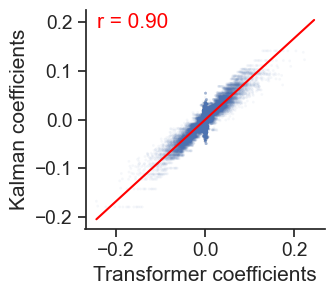

In [10]:
def unroll_transformer_coefficients(state, xs):
    """Return the average Transformer block coefficient matrix for the interpretable model."""
    pred, info = state.apply_fn({"params": state.params}, xs, mutable="intermediates")
    att = np.asarray(
        info["intermediates"]["TransformerBlock_0"]["MultiHeadDotProductAttention_0"]["attention_weights"][0]
    ).squeeze()

    params = state.params
    E = np.asarray(params["Dense_0"]["kernel"])
    V = np.asarray(params["TransformerBlock_0"]["MultiHeadDotProductAttention_0"]["value"]["kernel"]).squeeze()
    O = np.asarray(params["TransformerBlock_0"]["MultiHeadDotProductAttention_0"]["out"]["kernel"]).squeeze()
    D = np.asarray(params["Dense_1"]["kernel"])
    learned_value_map = E @ V @ O @ D

    n_time = xs.shape[1]
    n_obs = xs.shape[2]
    coeff_acc = np.zeros(((n_time - 1) * n_obs, (n_time - 1) * n_obs))

    for batch_idx in range(xs.shape[0]):
        weights = att[batch_idx]
        block_rows = []
        for i in range(n_time - 1):
            row = []
            for j in range(n_time - 1):
                row.append(weights[i, j] * learned_value_map.T)
            block_rows.append(row)
        coeff_acc += np.block(block_rows)

    return coeff_acc / xs.shape[0]


set_task_shape(coeff_task, CFG.coeff_eval_length, CFG.coeff_eval_batch_size)
coeff_xs = next(coeff_task)

transformer_mat = unroll_transformer_coefficients(coeff_state, coeff_xs)
_, kalman_mat = pred_kalman(coeff_xs, coeff_task, return_mat=True)

nonzero = ~np.isclose(kalman_mat, 0)
transformer_vals = transformer_mat[nonzero]
kalman_vals = kalman_mat[nonzero]

slope = np.linalg.lstsq(transformer_vals[:, None], kalman_vals, rcond=None)[0][0]
corr = np.corrcoef(transformer_vals, kalman_vals)[0, 1]

fig, ax = plt.subplots(figsize=(3.6, 3.2))
ax.scatter(transformer_vals, kalman_vals, alpha=0.05, s=4, color="C0", edgecolors="none")
xlim = np.nanmax(np.abs(transformer_vals))
xline = np.linspace(-xlim, xlim, 200)
ax.plot(xline, slope * xline, color="red", linewidth=1.5)
ax.text(0.05, 0.92, f"r = {corr:.2f}", transform=ax.transAxes, color="red")
ax.set_xlabel("Transformer coefficients")
ax.set_ylabel("Kalman coefficients")
fig.tight_layout()

A high positive correlation means that the learned Transformer and the Kalman filter are using very similar linear coefficients. The exact scale can differ because the Transformer's representation is learned, but the entrywise relationship shows whether the learned computation has recovered the same structure as the Kalman recursion.

## 6. Half-Gaussian noise: violating the Kalman assumptions

The Kalman filter is optimal for linear systems with Gaussian process and observation noise. The next experiment keeps the linear dynamics but changes the process noise to a half-Gaussian distribution. This violates the Gaussian assumption while preserving a state-estimation problem that the Transformer can learn from data, and indeed the Transformer outperforms the Kalman filter in this setting.

In [8]:
half_states = {}
half_histories = {}
half_tasks = {}

for label, pos_emb in [("Transformer (NoPE)", False), ("Transformer (absolute PE)", True)]:
    half_task = KalmanFilterTask(
        length=CFG.half_train_length,
        n_dims=CFG.half_n_dims,
        n_obs_dims=CFG.half_n_dims,
        mode="ac",
        n_tasks=None,
        n_snaps=None,
        t_noise=CFG.half_t_noise,
        o_noise=CFG.half_o_noise,
        noise_dist="half",
        batch_size=CFG.half_batch_size,
        seed=CFG.seed + 10,
    )
    state, hist = timed_train(
        label,
        half_sweep_config(pos_emb),
        half_task,
        train_iters=CFG.half_iters,
        lr=CFG.half_lr,
    )
    half_states[label] = state
    half_histories[label] = hist
    half_tasks[label] = half_task

ITER 1000:  train_loss=0.6890   test_loss=0.5771
ITER 2000:  train_loss=0.5098   test_loss=0.4886
ITER 3000:  train_loss=0.4643   test_loss=0.4633
ITER 4000:  train_loss=0.4543   test_loss=0.4575
ITER 5000:  train_loss=0.4490   test_loss=0.4443
Transformer (NoPE): 52.4 seconds
ITER 1000:  train_loss=0.5949   test_loss=0.4344
ITER 2000:  train_loss=0.4349   test_loss=0.4440
ITER 3000:  train_loss=0.4296   test_loss=0.4363
ITER 4000:  train_loss=0.4257   test_loss=0.4272
ITER 5000:  train_loss=0.4255   test_loss=0.4189
Transformer (absolute PE): 52.5 seconds


(<Figure size 750x300 with 1 Axes>,
 <Axes: title={'center': 'Half-Gaussian noise: learned estimator versus Kalman filter'}, xlabel='Time', ylabel='MSE'>)

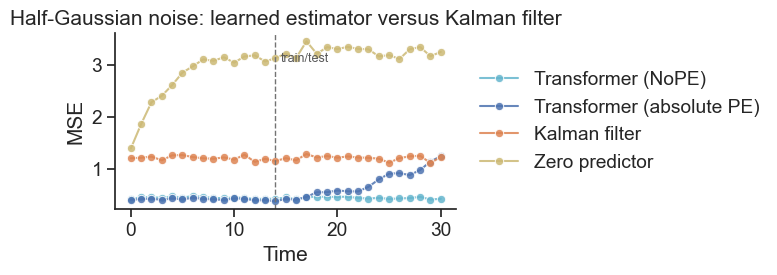

In [9]:
def evaluate_half_models(states, task):
    # Match demo.ipynb: evaluate by mutating the same task object used for training.
    # With n_tasks=None, A varies per example, but C is fixed by the task seed.
    # Reusing the task keeps the training/evaluation observation matrix distribution aligned.
    set_task_shape(task, CFG.half_eval_length, CFG.half_eval_batch_size)
    xs_full = next(task)
    A, C, observations = split_ac_batch(xs_full, task)
    time_index = np.arange(observations.shape[1] - 1)

    rows = []
    obs_start = task.n_dims + task.n_obs_dims
    for label, state in states.items():
        pred_full = np.asarray(state.apply_fn({"params": state.params}, xs_full))
        pred_obs = pred_full[:, obs_start:, :task.n_obs_dims]
        mse = ((observations[:, 1:] - pred_obs[:, :-1]) ** 2).mean(axis=(0, -1))
        rows.append(pd.DataFrame({"time": time_index, "mse": mse, "method": label}))

    kalman_pred, _ = pred_kalman(
        observations,
        task,
        A=A,
        C=C,
        t_noise=task.t_noise,
        o_noise=task.o_noise,
    )
    kalman_empirical = ((observations[:, 1:] - kalman_pred[:, :-1]) ** 2).mean(axis=(0, -1))
    zero_mse = (observations[:, 1:] ** 2).mean(axis=(0, -1))

    rows.extend([
        pd.DataFrame({"time": time_index, "mse": kalman_empirical, "method": "Kalman filter"}),
        pd.DataFrame({"time": time_index, "mse": zero_mse, "method": "Zero predictor"}),
    ])
    return pd.concat(rows, ignore_index=True)


half_eval_task = next(iter(half_tasks.values()))
half_df = evaluate_half_models(half_states, half_eval_task)
plot_mse_sweep(
    half_df,
    title="Half-Gaussian noise: learned estimator versus Kalman filter",
    train_length=CFG.half_train_length,
    yscale=None,
)

In this setting the Kalman filter is still a strong linear-Gaussian baseline, but it is no longer Bayes optimal for the true data-generating distribution. The Transformer can use training data to learn a predictor better matched to the half-Gaussian noise distribution.